In [7]:
# Cell 1: Install & Import (BiomedCLIP Version)
!pip install open_clip_torch transformers torch scikit-learn matplotlib pillow

import json
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

# Import OpenCLIP
import open_clip
from transformers import AutoTokenizer # Dùng tokenizer của HF cho Text

# --- CẤU HÌNH ---
# Model ID cho OpenCLIP (phải có prefix hf-hub:)
MODEL_NAME = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
TOKENIZER_ID = 'microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
BASE_PATH = '/kaggle/input/sumotosima/sumotosima_split'

BATCH_SIZE = 16
GRAD_ACCUMULATION_STEPS = 2
EPOCHS = 20
LEARNING_RATE = 1e-5 # BiomedCLIP đã hội tụ tốt, train LR nhỏ
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- XỬ LÝ DỮ LIỆU ---
def load_data(split_name):
    folder_path = os.path.join(BASE_PATH, split_name)
    img_folder = os.path.join(folder_path, 'images')
    jsonl_file = os.path.join(folder_path, f'metadata_{split_name}.jsonl')

    dataset = []
    if not os.path.exists(jsonl_file):
        print(f"⚠️ Không tìm thấy file {jsonl_file}")
        return []

    with open(jsonl_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                entry = json.loads(line)
                img_name = entry.get('file_name') or entry.get('image')
                caption = entry.get('text') or entry.get('caption')

                if img_name and caption:
                    dataset.append({
                        'image': img_name,
                        'caption': caption,
                        'img_folder_path': img_folder
                    })
            except json.JSONDecodeError:
                continue
    return dataset

# Load Data
print("Loading Data...")
train_data = load_data('train')
val_data = load_data('val')
test_data = load_data('test')

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Using device: cuda
Loading Data...
Train: 400 | Val: 50 | Test: 50


In [8]:
# Cell 2: BiomedCLIP Dataset & Model Init (OpenCLIP)

# 1. LOAD MODEL & TRANSFORMS TỪ OPEN_CLIP
print(f"Loading BiomedCLIP model...")
# create_model_and_transforms trả về: model, preprocess_train, preprocess_val
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(MODEL_NAME)
model = model.to(device)

# Load Tokenizer riêng từ Hugging Face (Vì OpenCLIP tokenizer mặc định không phải BERT)
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)

# Kích hoạt Gradient Checkpointing (Tiết kiệm RAM)
model.set_grad_checkpointing(True)

# 2. DATASET CLASS
class BiomedCLIPDataset(Dataset):
    def __init__(self, data_list, image_transform, tokenizer):
        self.data_list = data_list
        self.image_transform = image_transform # Hàm xử lý ảnh của OpenCLIP
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        item = self.data_list[idx]
        img_name = item['image']
        text = item['caption']
        current_img_folder = item['img_folder_path']
        img_path = os.path.join(current_img_folder, img_name)

        try:
            image = Image.open(img_path).convert("RGB")

            # 1. Xử lý ảnh (Dùng transform của OpenCLIP)
            # Kết quả là Tensor [3, 224, 224]
            pixel_values = self.image_transform(image)

            # 2. Xử lý Text (Dùng HF Tokenizer)
            text_inputs = self.tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=256, # BiomedCLIP hỗ trợ 256
                return_tensors="pt"
            )

            return {
                "pixel_values": pixel_values,
                "input_ids": text_inputs["input_ids"].squeeze(0),
                "attention_mask": text_inputs["attention_mask"].squeeze(0)
            }
        except Exception as e:
            # print(f"Error: {e}")
            return self.__getitem__((idx + 1) % len(self.data_list))

# 3. DATALOADER
# Lưu ý: Train dùng preprocess_train (có augmentation), Val/Test dùng preprocess_val
train_dataset = BiomedCLIPDataset(train_data, preprocess_train, tokenizer)
val_dataset = BiomedCLIPDataset(val_data, preprocess_val, tokenizer)
test_dataset = BiomedCLIPDataset(test_data, preprocess_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"BiomedCLIP Ready! Batch Size: {BATCH_SIZE}")

Loading BiomedCLIP model...
BiomedCLIP Ready! Batch Size: 16


In [9]:
# Cell 3: Training Loop with Progress Bar (tqdm)
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import gc
import os
from tqdm.auto import tqdm  # Thư viện thanh tiến trình

# Cleanup
gc.collect()
torch.cuda.empty_cache()

BEST_MODEL_PATH = "/content/best_biomed_clip.pt"
best_val_loss = float('inf')
loss_history = {'train': [], 'val': []}

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = GradScaler('cuda')

print("Start Training BiomedCLIP (OpenCLIP)...")

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    # Dùng tqdm bọc train_loader để hiện thanh tiến trình
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{EPOCHS}")

    for i, batch in progress_bar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)

        with autocast('cuda'):
            image_features = model.encode_image(pixel_values)
            text_features = model.encode_text(input_ids) # Đã bỏ attention_mask

            image_features = F.normalize(image_features, dim=-1)
            text_features = F.normalize(text_features, dim=-1)

            logit_scale = model.logit_scale.exp().clamp(max=100)

            logits_per_image = logit_scale * image_features @ text_features.t()
            logits_per_text = logit_scale * text_features @ image_features.t()

            batch_size_curr = image_features.size(0)
            ground_truth = torch.arange(batch_size_curr, dtype=torch.long, device=device)

            loss = (loss_fn(logits_per_image, ground_truth) + loss_fn(logits_per_text, ground_truth)) / 2
            loss = loss / GRAD_ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % GRAD_ACCUMULATION_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        current_loss = loss.item() * GRAD_ACCUMULATION_STEPS
        total_train_loss += current_loss

        # Cập nhật loss lên thanh tiến trình thay vì print
        progress_bar.set_postfix({"Train Loss": f"{current_loss:.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)
    loss_history['train'].append(avg_train_loss)

    # --- VALIDATION ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)

            with autocast('cuda'):
                image_features = model.encode_image(pixel_values)
                text_features = model.encode_text(input_ids)

                image_features = F.normalize(image_features, dim=-1)
                text_features = F.normalize(text_features, dim=-1)

                logit_scale = model.logit_scale.exp().clamp(max=100)
                logits = logit_scale * image_features @ text_features.t()

                ground_truth = torch.arange(image_features.size(0), dtype=torch.long, device=device)
                val_loss_batch = loss_fn(logits, ground_truth)

            total_val_loss += val_loss_batch.item()

    avg_val_loss = total_val_loss / len(val_loader)
    loss_history['val'].append(avg_val_loss)

    # Print kết quả cuối Epoch
    print(f"Summary Ep {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- SAVE BEST ---
    if avg_val_loss < best_val_loss:
        print(f"🚀 New Best Model! ({best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving...")
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        with open("/content/tokenizer_config.txt", "w") as f:
            f.write(TOKENIZER_ID)

print("Training Completed!")

Start Training BiomedCLIP (OpenCLIP)...


Epoch 1/20:   0%|          | 0/25 [00:00<?, ?it/s]

Summary Ep 1: Train Loss: 3.4126 | Val Loss: 2.2949
🚀 New Best Model! (inf -> 2.2949). Saving...


Epoch 2/20:   0%|          | 0/25 [00:00<?, ?it/s]

Summary Ep 2: Train Loss: 1.8922 | Val Loss: 2.0032
🚀 New Best Model! (2.2949 -> 2.0032). Saving...


...

Summary Ep 18: Train Loss: 0.2649 | Val Loss: 3.3060


Epoch 19/20:   0%|          | 0/25 [00:00<?, ?it/s]

Summary Ep 19: Train Loss: 0.1862 | Val Loss: 3.3811


Epoch 20/20:   0%|          | 0/25 [00:00<?, ?it/s]

Summary Ep 20: Train Loss: 0.1936 | Val Loss: 3.3760
Training Completed!


🔄 Đang chuẩn bị Model để đánh giá...
✅ Tìm thấy Best Model tại /content/best_biomed_clip.pt. Đang load trọng số...
🚀 Đã load thành công Best Model!
Running evaluation on TEST Set...
Extracting features from 50 samples...
Calculating Metrics...

METRIC          | VALUE     
----------------------------
R@1             | 14.00%
R@5             | 60.00%
R@10            | 92.00%
P@1             | 14.00%
P@5             | 12.00%
P@10            | 9.20%
nDCG@1          | 0.1400
nDCG@5          | 0.3729
nDCG@10         | 0.4776
mAP             | 0.3491
MRR             | 0.35%



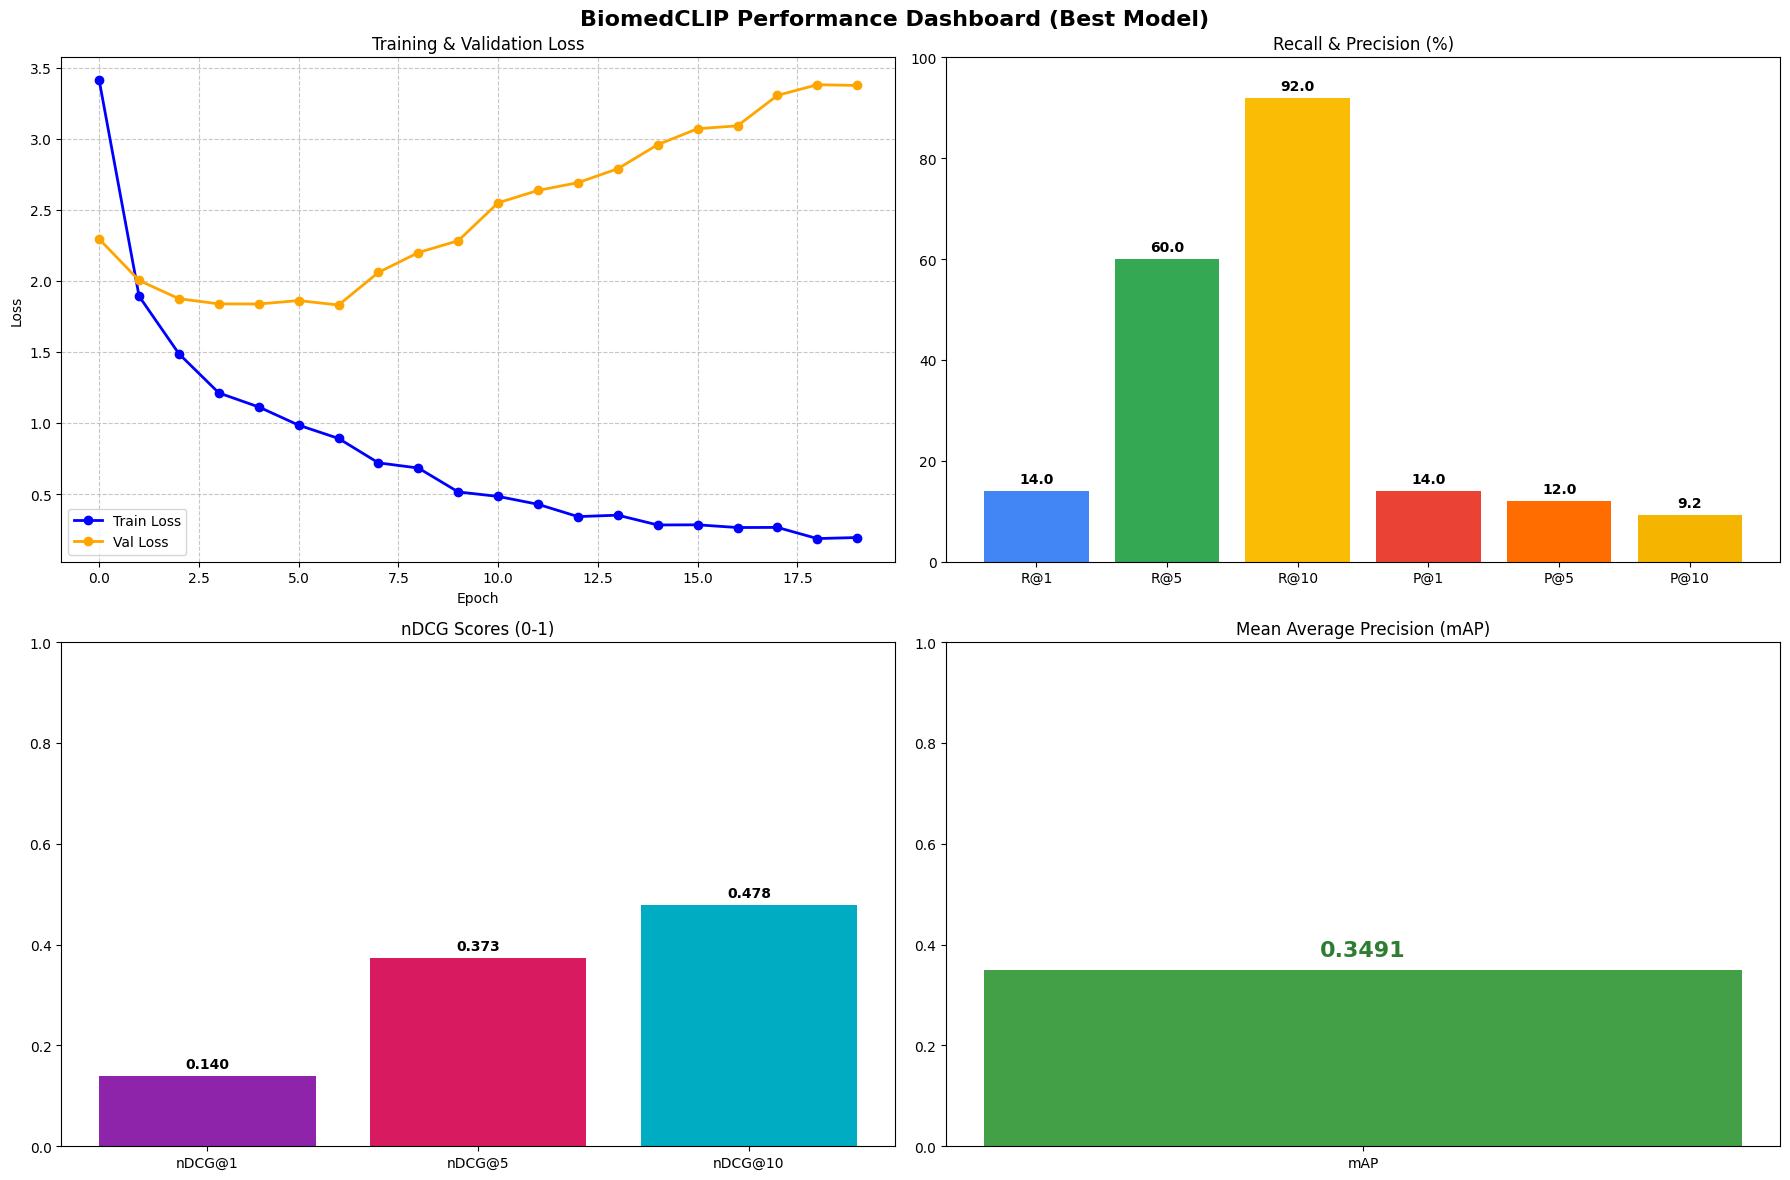

In [10]:
# Cell 4: BiomedCLIP Evaluation & Visualization (OpenCLIP Version)
import matplotlib.pyplot as plt
import numpy as np
import torch
import open_clip
from torch.amp import autocast
import os

# --- CẤU HÌNH ---
# Phải khớp với MODEL_NAME và PATH ở Cell 1 & 3
MODEL_NAME = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
BEST_MODEL_PATH = "/content/best_biomed_clip.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 1. LOAD BEST MODEL (OpenCLIP Style) ---
print(f"🔄 Đang chuẩn bị Model để đánh giá...")

# Khởi tạo kiến trúc rỗng
best_model, _, _ = open_clip.create_model_and_transforms(MODEL_NAME)
best_model = best_model.to(device)

if os.path.exists(BEST_MODEL_PATH):
    print(f"✅ Tìm thấy Best Model tại {BEST_MODEL_PATH}. Đang load trọng số...")
    try:
        # OpenCLIP lưu state_dict, nên ta load lại state_dict
        checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
        best_model.load_state_dict(checkpoint)
        print("🚀 Đã load thành công Best Model!")
    except Exception as e:
        print(f"❌ Lỗi khi load checkpoint: {e}")
        print("⚠️ Đang dùng model pre-trained gốc (chưa fine-tune).")
else:
    print("⚠️ Không tìm thấy file checkpoint. Đang dùng model pre-trained gốc.")

best_model.eval()

# --- 2. FEATURE EXTRACTION (OPEN_CLIP API) ---
def get_biomed_embeddings(dataloader, model):
    model.eval()
    image_embeds_list = []
    text_embeds_list = []

    print(f"Extracting features from {len(dataloader.dataset)} samples...")
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)

            with autocast('cuda'):
                # 1. Encode Image
                image_features = model.encode_image(pixel_values)

                # 2. Encode Text (QUAN TRỌNG: Không truyền attention_mask cho OpenCLIP)
                text_features = model.encode_text(input_ids)

                # 3. Normalize
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)

                # Đưa về CPU
                image_embeds_list.append(image_features.cpu().float())
                text_embeds_list.append(text_features.cpu().float())

    return torch.cat(image_embeds_list), torch.cat(text_embeds_list)

# --- 3. METRICS CALCULATION (Chuẩn hóa) ---
def calculate_ndcg(rel_scores, k):
    actual_len = len(rel_scores)
    k_effective = min(k, actual_len)
    if k_effective == 0: return 0.0
    dcg = np.sum((2**rel_scores[:k_effective] - 1) / np.log2(np.arange(2, k_effective + 2)))
    return dcg # IDCG=1 vì chỉ có 1 ground truth

def evaluate_metrics(image_embeds, text_embeds):
    print("Calculating Metrics...")
    similarity = text_embeds @ image_embeds.t()
    num_samples = similarity.shape[0]

    # Dynamic K (xử lý trường hợp test set nhỏ)
    k_eval = min(10, num_samples)

    metrics = {
        "R@1": [], "R@5": [], "R@10": [],
        "P@1": [], "P@5": [], "P@10": [],
        "nDCG@1": [], "nDCG@5": [], "nDCG@10": [],
        "AP": [],
        "RR": []
    }

    _, topk_indices = torch.topk(similarity, k=k_eval, dim=1)
    topk_indices = topk_indices.cpu().numpy()

    for i in range(num_samples):
        target_idx = i
        pred_indices = topk_indices[i]
        rel = np.array([1 if idx == target_idx else 0 for idx in pred_indices])

        def sum_rel_at_k(rel_arr, k):
            if k > len(rel_arr): return np.sum(rel_arr)
            return np.sum(rel_arr[:k])

        # Recall
        metrics["R@1"].append(1 if sum_rel_at_k(rel, 1) > 0 else 0)
        metrics["R@5"].append(1 if sum_rel_at_k(rel, 5) > 0 else 0)
        metrics["R@10"].append(1 if sum_rel_at_k(rel, 10) > 0 else 0)

        # Precision
        metrics["P@1"].append(sum_rel_at_k(rel, 1) / 1)
        metrics["P@5"].append(sum_rel_at_k(rel, 5) / 5)
        metrics["P@10"].append(sum_rel_at_k(rel, 10) / 10)

        # nDCG
        metrics["nDCG@1"].append(calculate_ndcg(rel, 1))
        metrics["nDCG@5"].append(calculate_ndcg(rel, 5))
        metrics["nDCG@10"].append(calculate_ndcg(rel, 10))

        # mAP
        found_at = np.where(rel == 1)[0]
        if len(found_at) > 0:
            rank = found_at[0] + 1
            metrics["AP"].append(1 / rank)
        else:
            rank_full = (similarity[i] > similarity[i, target_idx]).sum().item() + 1
            metrics["AP"].append(1 / rank_full)

        if len(found_at) > 0:
            rank = found_at[0] + 1
            metrics["RR"].append(1 / rank)
        else:
            rank_full = (similarity[i] > similarity[i, target_idx]).sum().item() + 1
            metrics["RR"].append(1 / rank_full)

    final_metrics = {k: np.mean(v) * 100 for k, v in metrics.items()
                 if k not in ["AP", "RR"]}
    final_metrics["nDCG@1"] /= 100; final_metrics["nDCG@5"] /= 100; final_metrics["nDCG@10"] /= 100
    final_metrics["mAP"] = np.mean(metrics["AP"])
    final_metrics["MRR"] = np.mean(metrics["RR"])   # ⬅️ NEW

    return final_metrics

# --- 4. EXECUTE & VISUALIZE ---
print("Running evaluation on TEST Set...")
test_img_embeds, test_txt_embeds = get_biomed_embeddings(test_loader, best_model)
results = evaluate_metrics(test_img_embeds, test_txt_embeds)

# Print Table
print("\n" + "="*40)
print(f"{'METRIC':<15} | {'VALUE':<10}")
print("-" * 28)
for k, v in results.items():
    fmt = ".4f" if ("nDCG" in k or "mAP" in k) else ".2f"
    suffix = "%" if fmt == ".2f" else ""
    print(f"{k:<15} | {v:{fmt}}{suffix}")
print("="*40 + "\n")

# Dashboard
fig, ax = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('BiomedCLIP Performance Dashboard (Best Model)', fontsize=16, fontweight='bold')

# Colors
colors_recall = ['#4285F4', '#34A853', '#FBBC05']
colors_prec = ['#EA4335', '#FF6D01', '#F4B400']
colors_rank = ['#8E24AA', '#D81B60', '#00ACC1', '#43A047']

# Chart 1: Training Loss
if 'loss_history' in globals() and loss_history['train']:
    ax[0, 0].plot(loss_history['train'], label='Train Loss', marker='o', color='blue', linewidth=2)
    if loss_history['val']:
        ax[0, 0].plot(loss_history['val'], label='Val Loss', marker='o', color='orange', linewidth=2)
    ax[0, 0].set_title('Training & Validation Loss')
    ax[0, 0].set_xlabel('Epoch')
    ax[0, 0].set_ylabel('Loss')
    ax[0, 0].legend()
    ax[0, 0].grid(True, linestyle='--', alpha=0.7)
else:
    ax[0, 0].text(0.5, 0.5, 'No Loss Data', ha='center')

# Chart 2: Recall & Precision
labels_rp = ['R@1', 'R@5', 'R@10', 'P@1', 'P@5', 'P@10']
values_rp = [results[k] for k in labels_rp]
bars2 = ax[0, 1].bar(labels_rp, values_rp, color=colors_recall + colors_prec)
ax[0, 1].set_title('Recall & Precision (%)')
ax[0, 1].set_ylim(0, 100)
for bar in bars2:
    height = bar.get_height()
    ax[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

# Chart 3: nDCG
labels_ndcg = ['nDCG@1', 'nDCG@5', 'nDCG@10']
values_ndcg = [results[k] for k in labels_ndcg]
bars3 = ax[1, 0].bar(labels_ndcg, values_ndcg, color=colors_rank[:3])
ax[1, 0].set_title('nDCG Scores (0-1)')
ax[1, 0].set_ylim(0, 1)
for bar in bars3:
    height = bar.get_height()
    ax[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Chart 4: mAP
ax[1, 1].bar(['mAP'], [results['mAP']], color=colors_rank[3], width=0.4)
ax[1, 1].set_title('Mean Average Precision (mAP)')
ax[1, 1].set_ylim(0, 1)
ax[1, 1].text(0, results['mAP'] + 0.02, f"{results['mAP']:.4f}", ha='center', va='bottom', fontsize=16, fontweight='bold', color='#2E7D32')

plt.tight_layout()
plt.show()